## Governing Equations (Expanded Form)

The reduced-order model keeps the same internal-resonance notation as before, with one extra electrical signal from the sensor piezo, $v_p$.

The coupled equations are

$$
\ddot{u}_1 + 2\varepsilon\mu_1\dot{u}_1 + \omega_1^2 u_1 = k_1 u_1 v_p + \varepsilon f_1\cos(\Omega t),
$$

$$
\ddot{u}_2 + 2\varepsilon\mu_2\dot{u}_2 + \omega_2^2 u_2 = k_2 u_1^2 + \Gamma v_p + \varepsilon^2 f_2\cos(\Omega t).
$$

Here, $u_1$ is parametrically excited by the sensor voltage $v_p$, and the $u_2$ equation also includes the piezo coupling term \(\Gamma v_p\).

The sensor piezo voltage is a solved state in the ODE system. Its dynamics are written explicitly as

$$
C_{p,s}\dot{v}_p + \frac{1}{R_s}v_p + \theta_s \dot{u}_2 = 0,
$$

or equivalently

$$
\dot{v}_p = -\frac{1}{R_s C_{p,s}}v_p - \frac{\theta_s}{C_{p,s}}\dot{u}_2.
$$

If the sensor is treated as open-circuit, then $R_s \to \infty$ and

$$
\dot{v}_p = -\frac{\theta_s}{C_{p,s}}\dot{u}_2.
$$

To integrate with `solve_ivp`, we use the first-order state

$$
\mathbf{y} = [u_1,\; v_1,\; u_2,\; v_2,\; v_p]^T,
\qquad v_1 = \dot{u}_1,\; v_2 = \dot{u}_2,
$$

with

$$
\dot{u}_1 = v_1,
$$

$$
\dot{v}_1 = -\omega_1^2 u_1 - 2\varepsilon\mu_1 v_1 + k_1 u_1 v_p + \varepsilon f_1\cos(\Omega t),
$$

$$
\dot{u}_2 = v_2,
$$

$$
\dot{v}_2 = -\omega_2^2 u_2 - 2\varepsilon\mu_2 v_2 + k_2 u_1^2 + \Gamma v_p + \varepsilon^2 f_2\cos(\Omega t),
$$

$$
\dot{v}_p = -\frac{1}{R_s C_{p,s}}v_p - \frac{\theta_s}{C_{p,s}}\dot{u}_2.
$$

Steady-state RMS amplitudes are computed after transient removal:

$$
A_i(f_2,\Omega) = \sqrt{\frac{1}{T_s}\int_{t_{\mathrm{trans}}}^{t_{\mathrm{end}}} u_i^2(t)\,dt},
\qquad i=1,2.
$$

In [222]:
import numpy as np
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib

# add project root to Python path (highest priority)
project_root = Path.cwd().parents[2]
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module
importlib.reload(rom1_module)
ROM = rom1_module.ROM

L_b = 185.9e-3
params_rom = PiezoBeamParams(
    rho_p=2700,
    rho_s=8500,
    s11=14.5e-12,
    E_s=70e9,
    d31=-19.5e-11,
    eps_r=1700,
    b=22.9e-3,
    hp=0.15e-3,
    hs=0.3e-3,
    n_patches=8,
    w_p=22.9e-3,
    w_s=22.9e-3,
    omega_p=110 * 2 * np.pi,
    omega_q=200 * 2 * np.pi,
)
params_rom.L_b = L_b
params_rom.xL = np.arange(1e-3, L_b, 24e-3)
params_rom.xR = params_rom.xL.copy() + 22.9e-3 
no_modes = 1
rom = ROM(params=params_rom, N=no_modes, modal_damping_ratios=np.array([0.0065] * no_modes))

# Patch roles: root actuator, tip sensor.
actuator_patch = slice(1, len(params_rom.xL) - 1)  # all but the last patch
sensor_patch = slice(0, None)  # the last patch

# ROM-derived coefficients used by the custom ODE.
omega_1 = float(rom.omega[0])
zeta_1 = float(rom.zeta[0])
theta_mech_actuator = np.sum((rom.p.theta_mech * rom.Gamma)[0, actuator_patch])
theta_mech_sensor = float((rom.p.theta_mech * rom.Gamma)[0, 0])
Cp_s = float(rom.p.Cp_scalar)
sigma_r = float(rom.sigma_r[0])
phi_tip = float(rom.mode_shape(0, rom.p.L_b))
phi_root = float(rom.mode_shape(0, 0.0))

# Backward-compatible aliases used in later cells.
theta_mech = theta_mech_actuator
theta_s = theta_mech_sensor

print('Actuator coupling theta_mech_actuator : ', theta_mech_actuator)
print('Sensor coupling theta_mech_sensor     : ', theta_mech_sensor)
print('Sensor capacitance Cp_s               : ', Cp_s)
print('First natural frequency               : ', omega_1 / (2 * np.pi))
print('Tip mode shape                        : ', phi_tip)


Actuator coupling theta_mech_actuator :  0.01134819955618379
Sensor coupling theta_mech_sensor     :  0.004901795588510522
Sensor capacitance Cp_s               :  8.690792561011494e-08
First natural frequency               :  9.851480159834734
Tip mode shape                        :  -16.722566085783413


In [223]:
params_rom.xL 

array([0.001, 0.025, 0.049, 0.073, 0.097, 0.121, 0.145, 0.169])

## Experimental vs Model Overlay (Analyze Linear + piezo_beam_FRF)
This section loads one experimental `.npz` file from `synthetic_impedance/Exp`, computes the FRF with Welch averaging, and overlays it with the analytical model from `ROM1.py`.

In [224]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd


def estimate_frf_welch(base_signal, tip_signal, fs, trial_dur=4, overlap_frac=0.1, nfft_mult=4, window="hann"):
    """Estimate FRF using Welch/CSD with H1/H2 and geometric mean Hv."""
    nperseg = int(trial_dur * fs)
    noverlap = int(nperseg * overlap_frac)
    nfft = nperseg * nfft_mult

    freq, Sx = welch(base_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sy = welch(tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sxy = csd(base_signal, tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

    H1 = Sxy / Sx
    H2 = Sy / Sxy
    Hv = np.sqrt(H1 * H2)
    return freq, Hv, H1, H2


def _to_plain_dict(obj):
    """Convert loaded object to a plain dict when possible."""
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.size == 1:
        maybe = obj.item()
        if isinstance(maybe, dict):
            return maybe
    return None


def load_experimental_dataset(data_path, name):
    """Load .npz or .mat experimental file with a unified result format."""
    p = Path(data_path)
    if not p.is_file():
        return {"name": name, "status": "failed", "error": f"file not found: {p}"}

    try:
        if p.suffix.lower() == ".npz":
            with np.load(p, allow_pickle=True) as data:
                if "arr_0" in data.files:
                    arr0_dict = _to_plain_dict(data["arr_0"] )
                    raw = arr0_dict if arr0_dict is not None else {k: data[k] for k in data.files}
                else:
                    raw = {k: data[k] for k in data.files}
        elif p.suffix.lower() == ".mat":
            from scipy.io import loadmat
            mat_data = loadmat(p)
            raw = {k: v for k, v in mat_data.items() if not k.startswith("__")}
        else:
            return {"name": name, "status": "failed", "error": f"unsupported file type: {p.suffix}"}

        return {"name": name, "status": "loaded", "path": p, "raw": raw}
    except Exception as e:
        return {"name": name, "status": "failed", "error": str(e)}


def extract_frf_from_dataset(d):
    """Return freq and FRF magnitude from either precomputed FRF fields or raw signals."""
    # Case 1: precomputed FRF exists in file.
    if "freq" in d:
        freq = np.asarray(d["freq"]).squeeze()
        for key in ["frf_mag", "frf_data", "FRF", "magnitude", "H_exp", "Hv"]:
            if key in d:
                frf = np.asarray(d[key]).squeeze()
                return freq, np.abs(frf), None, None

    # Case 2: raw time series; compute FRF via Welch.
    fs_key = "Fs" if "Fs" in d else ("fs" if "fs" in d else None)
    base_key = "base_accel" if "base_accel" in d else ("base_signal" if "base_signal" in d else None)
    tip_key = "tip_signal" if "tip_signal" in d else ("tip_vel" if "tip_vel" in d else None)

    if fs_key is None or base_key is None or tip_key is None:
        missing = []
        if fs_key is None:
            missing.append("Fs/fs")
        if base_key is None:
            missing.append("base_accel/base_signal")
        if tip_key is None:
            missing.append("tip_signal/tip_vel")
        raise KeyError("missing keys: " + ", ".join(missing))

    fs = float(np.asarray(d[fs_key]).squeeze())
    freq, H_exp, H1, H2 = estimate_frf_welch(
        base_signal=np.asarray(d[base_key]).squeeze(),
        tip_signal=np.asarray(d[tip_key]).squeeze(),
        fs=fs,
        trial_dur=d.get('trial_dur', 2),
        overlap_frac=0.4,
        nfft_mult=4,
        window="hann",
    )
    return freq, np.abs(H_exp), H1, H2


# Experimental datasets: path and styling for each configuration (merged dictionary).
exp_datasets = {
    # "SC": {
    #     "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\SC.npz",
    #     # 'path':r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\dat_Dec\1_Negative_capacitance\SC.npz",
    #     "color": "blue", "linestyle": "-", "linewidth": 2
    # },
    "OC": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\April2026\7\Chris_beam_003.npz",
        "color": "red", "linestyle": "-", "linewidth": 2
    },
    # "shunt_LR_OB": {
    #     "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt_LR_OB.npz",
    #     "color": "green", "linestyle": "-", "linewidth": 2
    # },
    # "shunt_negative cap.": {
    #     "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt.npz",
    #     "color": "purple", "linestyle": "-", "linewidth": 2
    # },
}
simulation_cases = {
    "OC_simu": {
        "K_p": 1e-5, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "red", "linestyle": "--", "linewidth": 1.5
    },
}

# Load all datasets.
exp_loaded = {}
for name, config in exp_datasets.items():
    exp_loaded[name] = load_experimental_dataset(config["path"], name)

print("Experimental datasets:")
for name, item in exp_loaded.items():
    if item["status"] == "loaded":
        print(f"  loaded: {name} -> {item['path']}")
    else:
        print(f"  failed: {name} -> {item.get('error', 'unknown error')}")

# Compute/get FRF for all successfully loaded files.
exp_frf_data = {}
for name, item in exp_loaded.items():
    if item["status"] != "loaded":
        continue

    d = item["raw"]
    try:
        freq, mag, H1, H2 = extract_frf_from_dataset(d)
        exp_frf_data[name] = {
            "freq": freq,
            "mag": mag,
            "H1": H1,
            "H2": H2,
        }
    except Exception as e:
        print(f"  failed FRF extraction: {name} -> {e}")

if not exp_frf_data:
    raise RuntimeError("No experimental dataset produced a plottable FRF.")


Experimental datasets:
  loaded: OC -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\April2026\7\Chris_beam_003.npz


  computed: OC_simu


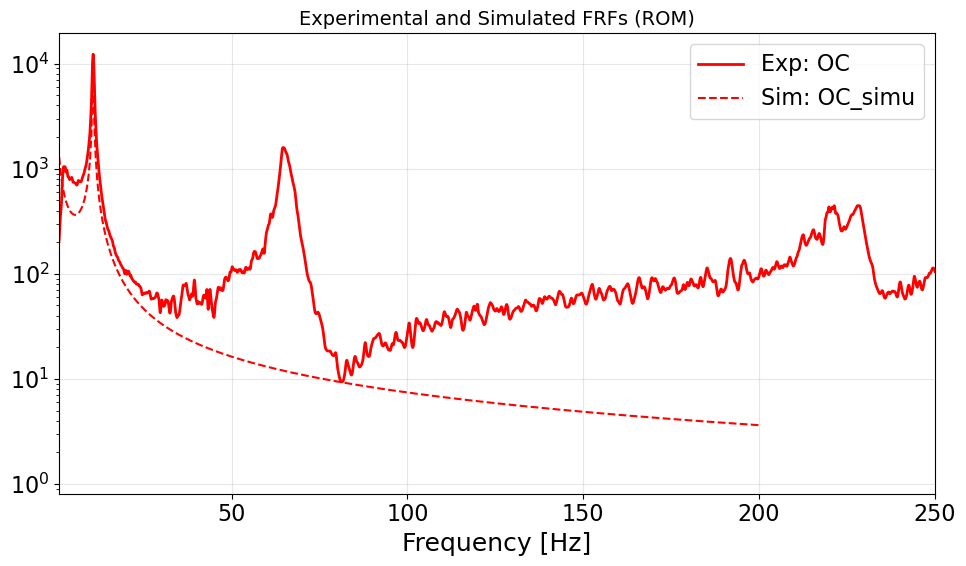


Plot complete. Experimental datasets: 1, Simulations: 1


In [225]:


# Frequency sweep for ROM (same for all cases).
omega_rom = np.linspace(1, 200, 500)*2 * np.pi 

# Simulation cases: define control parameters and styling for each configuration (merged dictionary).


# Compute ROM responses for all simulation cases.
sim_frf_data = {}
for case_name, params in simulation_cases.items():
    try:
        ode_sys = rom.build_ode_system_base_excitation(
            a_base=lambda t: 1.0,
            j_exc=None,
            R_c=params["R_c"],
            K_p=params["K_p"],
            K_i=params["K_i"],
            K_c=params["K_c"],
            negative_capacitance_ratio=params.get("negative_capacitance_ratio", 0.0),
            base_accel_amp=1.0,
            freq_domain_amps=None,
        )
        
        freq_sim, rom_disp, rom_veloc = rom.frequency_response_fe3(
            ode_system=ode_sys,
            w=omega_rom,
            x_eval=np.linspace(0.0, params_rom.L_b, 20),
        )
        
        sim_frf_data[case_name] = {
            "freq": freq_sim,
            "mag": np.abs(rom_veloc[-1, :] 
             + 1/(1j*freq_sim*2*np.pi)
            ),
        }
        print(f"  computed: {case_name}")
    except Exception as e:
        print(f"  failed simulation: {case_name} -> {e}")

# ============= PLOTTING =============
plt.rcParams.update({
	"font.size": 9*2,
	"axes.labelsize": 9*2,
	"xtick.labelsize": 8*2,
	"ytick.labelsize": 8*2,
	"legend.fontsize": 8*2,
})
plt.figure(figsize=(10, 6))

# # Plot all experimental FRFs.
for name, item in exp_frf_data.items():
    config = exp_datasets.get(name, {})
    style = {"color": config.get("color", "black"), "linestyle": config.get("linestyle", "-"), "linewidth": config.get("linewidth", 2), "marker": config.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"], label=f"Exp: {name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])

# Plot all simulation FRFs.
for case_name, item in sim_frf_data.items():
    params = simulation_cases.get(case_name, {})
    style = {"color": params.get("color", "gray"), "linestyle": params.get("linestyle", "--"), "linewidth": params.get("linewidth", 1.5),
             'marker': params.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"]*1000*8, label=f"Sim: {case_name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])


plt.xlim([1, 250])
plt.xlabel("Frequency [Hz]",)
# plt.ylabel("Magnitude", fontsize=12)
# plt.ylim([1, 50e3])
plt.title("Experimental and Simulated FRFs (ROM)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend( loc="best")
plt.tight_layout()
plt.show()

print(f"\nPlot complete. Experimental datasets: {len(exp_frf_data)}, Simulations: {len(sim_frf_data)}")

In [226]:

item["mag"]

# item["freq"]
# case_name

array([1.61375491e-01, 1.16912616e-01, 9.26102962e-02, 7.75111674e-02,
       6.73998875e-02, 6.03141421e-02, 5.52219480e-02, 5.15341747e-02,
       4.88960586e-02, 4.70882594e-02, 4.59765265e-02, 4.54853463e-02,
       4.55848615e-02, 4.62864618e-02, 4.76456946e-02, 4.97736790e-02,
       5.28614900e-02, 5.72282644e-02, 6.34185322e-02, 7.24141791e-02,
       8.61517027e-02, 1.09013146e-01, 1.53389760e-01, 2.72903921e-01,
       1.31831556e+00, 3.63518912e-01, 1.62332203e-01, 1.02516774e-01,
       7.40306703e-02, 5.74473395e-02, 4.66386531e-02, 3.90619887e-02,
       3.34735159e-02, 2.91932473e-02, 2.58183115e-02, 2.30949953e-02,
       2.08556682e-02, 1.89852024e-02, 1.74019640e-02, 1.60464971e-02,
       1.48745011e-02, 1.38523126e-02, 1.29539107e-02, 1.21588774e-02,
       1.14509768e-02, 1.08171443e-02, 1.02467549e-02, 9.73108379e-03,
       9.26290394e-03, 8.83618114e-03, 8.44584021e-03, 8.08758398e-03,
       7.75775138e-03, 7.45320543e-03, 7.17124389e-03, 6.90952745e-03,
      

In [227]:
print('Electromechanical coupling= ', (rom.p.theta_mech * rom.Gamma)[0,0])
print('C_p_eq= ', rom.p.Cp_scalar*1e9)
print('First natural frequency (undamped) = ', rom.omega/(2*np.pi))


Electromechanical coupling=  0.004901795588510522
C_p_eq=  86.90792561011494
First natural frequency (undamped) =  [9.85148016]


In [228]:
# -----------------------------
# Calibration from the nondimensional study
# -----------------------------
# Targets from Oueini_scipy_nondim.ipynb
mu1_bar_target = 6e-2
mu2_bar_target = 6.5e-3
k1_over_k2_target = 1.0
f2_bar_nominal = 1.5e-3
f2_bar_target_min = 0.5 * f2_bar_nominal
f2_bar_target_max = 2 * f2_bar_nominal

# Physical excitation range available in the experiment/simulation.
# Keep this explicit in base-acceleration units so the mapping is transparent.
a_base_values_g = np.linspace(5, 30, 20) * 1e-3
a_base_values = a_base_values_g * 9.81
a_base_min = a_base_values.min()
a_base_max = a_base_values.max()

theta_mech = float((rom.p.theta_mech * rom.Gamma)[0, 0])
sigma_r = float(rom.sigma_r)

# Use the same primary frequency scale already used in the physical notebook.
eps = 1
sigma2 = 0.0
freq_scale = 1
w1 = rom.omega[0] /2 
w2 = 2 * w1 - eps * sigma2
R_s = 1e8
# Match the nondimensional damping targets.
mu1 = mu1_bar_target * w1
mu2 = mu2_bar_target * w1
mu1_bar_recovered = mu1 / w1
mu2_bar_recovered = mu2 / w1

# Base acceleration enters the modal equation through rom.sigma_r.
F2_values = sigma_r * a_base_values
F2_min = F2_values.min()
F2_max = F2_values.max()

# Calibrate k2 from the available physical forcing span to the target nondimensional span.
f2_bar_span_target = f2_bar_target_max - f2_bar_target_min
F2_span = F2_max - F2_min
if np.isclose(F2_span, 0.0):
    raise ValueError('Physical forcing span is zero; cannot calibrate k2 from the excitation range.')

k2 = f2_bar_nominal / F2_values[len(F2_values) //2] * (w1**4 / theta_mech_actuator)
k1 = - k1_over_k2_target * k2 / theta_mech_sensor * Cp_s 
f1 = 0.0

# Diagnostics: mapped nondimensional forcing using the actual ODE input.
f2_bar_values = theta_mech_actuator * k2 * F2_values / (w1**4)
f2_bar_recovered_min = f2_bar_values.min()
f2_bar_recovered_max = f2_bar_values.max()

print('=== CALIBRATION SUMMARY ===')
print(f'theta_mech = {theta_mech:0.6e}')
print(f'rom.sigma_r = {sigma_r:0.6e}')
print(f'w1 / (2 pi) = {w1 / (2 * np.pi):0.6f} Hz')
print(f'w2 / (2 pi) = {w2 / (2 * np.pi):0.6f} Hz')
print()
print('Target nondimensional damping:')
print(f'  mu1_bar_target = {mu1_bar_target:0.6e}, recovered = {mu1_bar_recovered:0.6e}')
print(f'  mu2_bar_target = {mu2_bar_target:0.6e}, recovered = {mu2_bar_recovered:0.6e}')
print()
print('Target nondimensional forcing range:')
print(f'  target f2_bar range = [{f2_bar_target_min:0.6e}, {f2_bar_target_max:0.6e}]')
print(f'  recovered f2_bar range = [{f2_bar_recovered_min:0.6e}, {f2_bar_recovered_max:0.6e}]')
print()
print('Physical excitation range:')
print(f'  a_base range [g] = [{a_base_values_g.min():0.6f}, {a_base_values_g.max():0.6f}]')
print(f'  a_base range [m/s^2] = [{a_base_min:0.6e}, {a_base_max:0.6e}]')
print(f'  modal forcing range F2 = sigma_r * a_base = [{F2_min:0.6e}, {F2_max:0.6e}]')
print()
print('Recovered dimensional parameters:')
print(f'  mu1 = {mu1:0.6e}')
print(f'  mu2 = {mu2:0.6e}')
print(f'  k1 = {k1:0.6e}')
print(f'  k2 = {k2:0.6e}')
print(f'  k1 / k2 = {k1 / k2:0.6e}')

if not np.isclose(f2_bar_recovered_min, f2_bar_target_min, rtol=1e-2, atol=1e-12):
    print('WARNING: span matching reproduces the nondimensional forcing span exactly, but not the lower endpoint.')


=== CALIBRATION SUMMARY ===
theta_mech = 4.901796e-03
rom.sigma_r = 9.364496e-02
w1 / (2 pi) = 4.925740 Hz
w2 / (2 pi) = 9.851480 Hz

Target nondimensional damping:
  mu1_bar_target = 6.000000e-02, recovered = 6.000000e-02
  mu2_bar_target = 6.500000e-03, recovered = 6.500000e-03

Target nondimensional forcing range:
  target f2_bar range = [7.500000e-04, 3.000000e-03]
  recovered f2_bar range = [4.130435e-04, 2.478261e-03]

Physical excitation range:
  a_base range [g] = [0.005000, 0.030000]
  a_base range [m/s^2] = [4.905000e-02, 2.943000e-01]
  modal forcing range F2 = sigma_r * a_base = [4.593285e-03, 2.755971e-02]

Recovered dimensional parameters:
  mu1 = 1.856960e+00
  mu2 = 2.011707e-01
  k1 = -1.289006e+02
  k2 = 7.270275e+06
  k1 / k2 = -1.772981e-05


C:\Users\setemadi3\AppData\Local\Temp\ipykernel_43440\1159125779.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_r = float(rom.sigma_r)


In [239]:
k2**0.5

np.float64(2696.3447545151935)

In [229]:
import time
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# -----------------------------
# Physical sweep using the calibrated parameters
# -----------------------------
freq_ratio_values = np.linspace(0.95, 1.05, 10)
samples_per_period = 100
n_periods_total = 500
n_periods_transient = n_periods_total - 100

omega_exc_values = freq_ratio_values * w2

rtol = 1e-8
atol = 1e-9

print('=== PHYSICAL SWEEP SETUP ===')
print(f'Electromechanical coupling theta_mech = {theta_mech:0.6e}')
print(f'C_p_eq = {rom.p.Cp_scalar * 1e9:0.6f} nF')
print(f'First natural frequency (ROM undamped) = {rom.omega / (2 * np.pi)} Hz')
print(f'2 mu1 = {2 * mu1:0.6e}')
print(f'2 mu2 = {2 * mu2:0.6e}')

def rhs(t, y, F2_amp, omega_exc):
    u1, v1, u2, v2, vp = y

    F2 = F2_amp * np.cos(omega_exc * t)

    du1 = v1
    dv1 = -w1**2 * u1 - 2 * mu1 * v1 + k1 * u1 * vp 
    du2 = v2
    dv2 = -w2**2 * u2 - 2 * mu2 * v2 + theta_mech_actuator * k2 * u1**2 + theta_mech_sensor * vp + F2
    dvp = -(1.0 / (R_s * Cp_s)) * vp - (theta_mech_sensor / Cp_s) * v2

    return np.array([du1, dv1, du2, dv2, dvp])

def run_case_ivp(F2_amp, omega_exc, y0=None):
    dt = 2 * pi / (samples_per_period * omega_exc)
    t_end = n_periods_total * 2 * pi / omega_exc
    t_trans = n_periods_transient * 2 * pi / omega_exc

    n_steps = int(np.round(t_end / dt))
    t_eval = np.linspace(0.0, n_steps * dt, n_steps + 1)

    if y0 is None:
        y0 = np.array([0.0, 1e-3, 0.0, 0.0])

    t0 = time.perf_counter()
    sol = solve_ivp(
        rhs,
        [0.0, t_eval[-1]],
        y0,
        args=(F2_amp, omega_exc),
        t_eval=t_eval,
        method='RK45',
        rtol=rtol,
        atol=atol,
    )
    runtime = time.perf_counter() - t0

    mask = sol.t >= t_trans
    u1 = sol.y[0]
    u2 = sol.y[2]
    v2 = sol.y[3]

    a1_rms = np.sqrt(np.mean(u1[mask] ** 2))
    a2_rms = np.sqrt(np.mean(u2[mask] ** 2))
    v2_rms = np.sqrt(np.mean(v2[mask] ** 2))

    return {
        't': sol.t,
        'y': sol.y,
        'a1_rms': a1_rms,
        'a2_rms': a2_rms,
        'v2_rms': v2_rms,
        'runtime_s': runtime,
    }

def run_amplitude_column(j, F2_amp):
    """One amplitude column: keep frequency continuation sequential inside each worker."""
    y0_col = np.array([0.0, 1e-4, 0.0, 0.0, 0.0])
    col_a1 = np.zeros(len(freq_ratio_values))
    col_a2 = np.zeros(len(freq_ratio_values))
    col_v2 = np.zeros(len(freq_ratio_values))
    col_runtime = np.zeros(len(freq_ratio_values))

    for i, omega_exc in enumerate(omega_exc_values):
        out = run_case_ivp(F2_amp, omega_exc, y0=y0_col)
        col_a1[i] = out['a1_rms']
        col_a2[i] = out['a2_rms']
        col_v2[i] = out['v2_rms']
        col_runtime[i] = out['runtime_s']
        y0_col = out['y'][:, -1].copy()

    return j, col_a1, col_a2, col_v2, col_runtime

A1 = np.zeros((len(freq_ratio_values), len(F2_values)))
A2 = np.zeros((len(freq_ratio_values), len(F2_values)))
V2_RMS = np.zeros((len(freq_ratio_values), len(F2_values)))
RUNTIME = np.zeros((len(freq_ratio_values), len(F2_values)))

n_jobs = -1  # use all cores
t_sweep_start = time.perf_counter()
if HAS_JOBLIB:
    results = Parallel(n_jobs=n_jobs, backend='loky', verbose=12)(
        delayed(run_amplitude_column)(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    )
else:
    print('joblib not found, running sequential sweep.')
    results = [
        run_amplitude_column(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    ]
t_sweep_total = time.perf_counter() - t_sweep_start

for j, col_a1, col_a2, col_v2, col_runtime in results:
    A1[:, j] = col_a1
    A2[:, j] = col_a2
    V2_RMS[:, j] = col_v2
    RUNTIME[:, j] = col_runtime

print('Sweep completed (parallel over excitation-amplitude columns when joblib is available).')
print(f'Grid size: {A1.shape[0]} frequency points x {A1.shape[1]} amplitude points')
print(f'Average runtime per case: {np.mean(RUNTIME):.3f} s')
print(f'Total wall time: {t_sweep_total:.3f} s')

=== PHYSICAL SWEEP SETUP ===
Electromechanical coupling theta_mech = 4.901796e-03
C_p_eq = 86.907926 nF
First natural frequency (ROM undamped) = [9.85148016] Hz
2 mu1 = 3.713921e+00
2 mu2 = 4.023414e-01


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   3 out of  20 | elapsed:  1.4min remaining:  8.1min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  1.4min remaining:  4.3min
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  1.5min remaining:  2.7min
[Parallel(n_jobs=-1)]: Done   9 out of  20 | elapsed:  1.5min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:  1.5min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:  1.5min remaining:   48.3s
[Parallel(n_jobs=-1)]: Done  15 out of  20 | elapsed:  1.5min remaining:   30.1s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  2.1min remaining:   22.1s


Sweep completed (parallel over excitation-amplitude columns when joblib is available).
Grid size: 10 frequency points x 20 amplitude points
Average runtime per case: 7.879 s
Total wall time: 126.413 s


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  2.1min finished


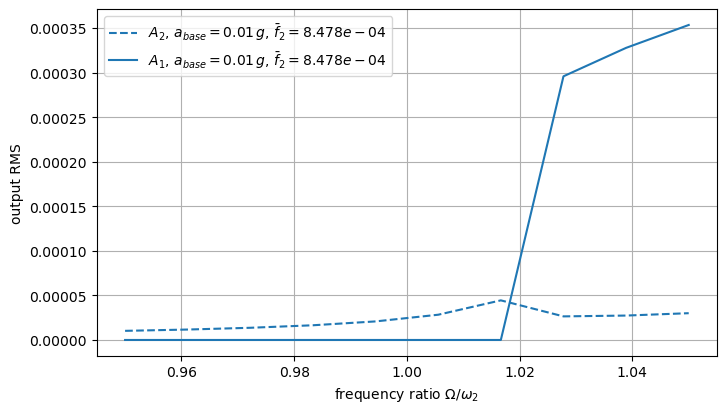

In [230]:
plt.rcdefaults()
pick_js = [0, len(a_base_values) // 2, len(a_base_values) - 1]
pick_js = [4]
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    label_a2 = fr"$A_2$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    label_a1 = fr"$A_1$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    l1, = plt.plot(freq_ratio_values, A2[:, j], "--",  label=label_a2)
    plt.plot(freq_ratio_values, A1[:, j], "-", color=l1.get_color(), label=label_a1)
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"output RMS")
# plt.title(r"$A_2$ frequency response slices (solve_ivp)")
plt.grid(True)
plt.legend()
plt.show()


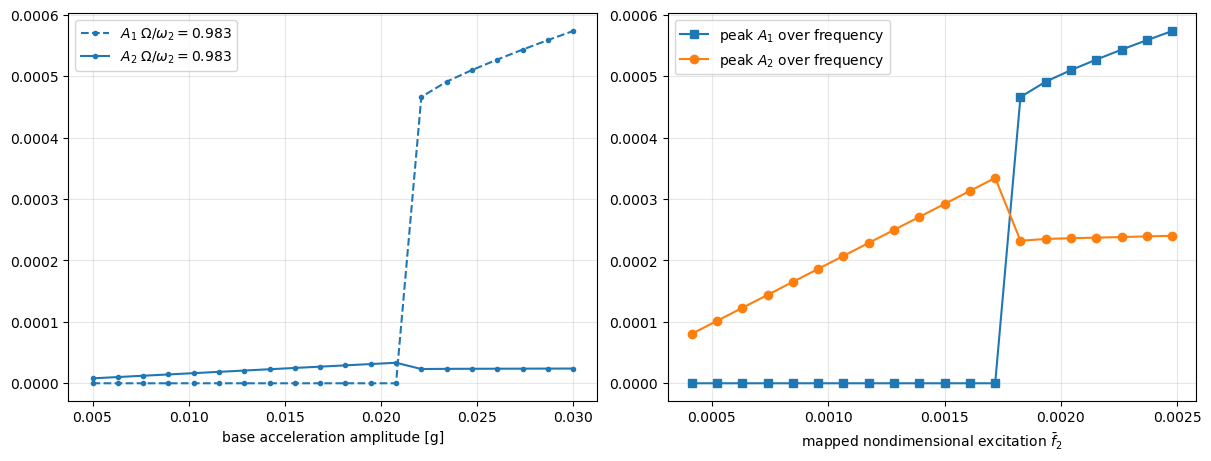

In [231]:

# ---- Amplitude vs excitation amplitude study ----
# 1) Fixed-frequency slices (near resonance).
target_ratios = [0.98]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for idx in idxs:
    r = freq_ratio_values[idx]
    l1, = axs[0].plot(a_base_values_g, A1[idx, :], '.--', label=fr"$A_1 \; \Omega/\omega_2={r:.3f}$")
    axs[0].plot(a_base_values_g, A2[idx, :], '.-', color=l1.get_color(),label=fr"$A_2 \; \Omega/\omega_2={r:.3f}$")

axs[0].set_xlabel(r"base acceleration amplitude [g]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()
idx = idxs[0]  # index for ratio closest to 1.00

axs[1].plot(f2_bar_values, A1[idx, :], "-s", label=r"peak $A_1$ over frequency")
axs[1].plot(f2_bar_values, A2[idx, :]*10, "-o", label=r"peak $A_2$ over frequency")
axs[1].set_xlabel(r"mapped nondimensional excitation $\bar{f}_2$")
axs[1].grid(True, alpha=0.3)
axs[1].legend()



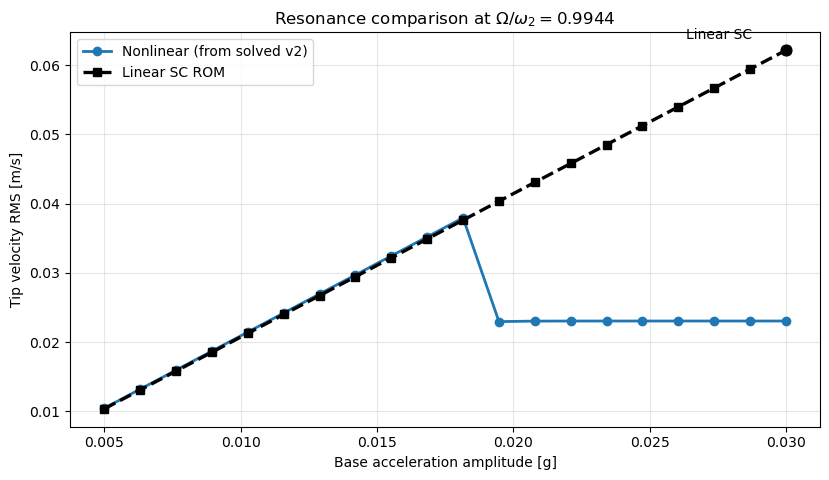

=== Resonance Velocity Comparison Summary ===
omega_res/(2*pi) = 9.796750 Hz
phi_tip (retained structural mode) = 1.672257e+01
Linear SC gain (tip peak velocity / base accel) = 2.986652e-01 (m/s)/(m/s^2)
Linear SC curve is the black dashed line with square markers.
Note: linear curve converted peak->RMS with 1/sqrt(2).


In [232]:
# --- Resonance comparison: nonlinear vs linear SC in LDV tip-velocity RMS ---

# Resonance index consistent with cell-12 sweep definition.
idx_res = int(np.argmin(np.abs(freq_ratio_values - 1.00)))
omega_res = float(omega_exc_values[idx_res])

# Single retained structural mode shape at tip (x = L_b).
phi_tip = float(np.abs(rom.mode_shape(0, rom.p.L_b)))

# Nonlinear structural velocity RMS from direct solved derivative state (v2), then map to tip.
v_struct_rms_nl = V2_RMS[idx_res, :]
v_tip_rms_nl = phi_tip * v_struct_rms_nl

# Linear SC tip-velocity RMS at the same resonance frequency.
sc_params = {
    'R_c': 1e4,
    'K_p': np.array([0]+[10e5]*7),
    'K_i': 0.0,
    'K_c': 0.0,
    'negative_capacitance_ratio': 0.0,
}

ode_sc = rom.build_ode_system_base_excitation(
    a_base=lambda t: 1.0,
    j_exc=None,
    R_c=sc_params['R_c'],
    K_p=sc_params['K_p'],
    K_i=sc_params['K_i'],
    K_c=sc_params['K_c'],
    negative_capacitance_ratio=sc_params['negative_capacitance_ratio'],
    base_accel_amp=1.0,
    freq_domain_amps=None,
)

# x_eval at tip only; velocity output is complex peak amplitude in frequency domain.
_, _, v_sc_tip = rom.frequency_response_fe3(
    ode_system=ode_sc,
    w=np.array([omega_res]),
    x_eval=np.array([rom.p.L_b]),
)

v_tip_peak_per_acc = float(np.abs(v_sc_tip[0, 0]))  # (m/s) per (m/s^2)
v_tip_rms_lin = (v_tip_peak_per_acc * a_base_values) / np.sqrt(2.0) 

fig, ax = plt.subplots(figsize=(8.4, 4.9))
ax.plot(
    a_base_values_g,
    v_tip_rms_nl,
    color='tab:blue',
    marker='o',
    lw=2.0,
    ms=6,
    label='Nonlinear (from solved v2)',
    zorder=3,
)
ax.plot(
    a_base_values_g,
    v_tip_rms_lin,
    color='black',
    marker='s',
    ls='--',
    lw=2.4,
    ms=6,
    label='Linear SC ROM',
    zorder=4,
)

# Mark the linear curve endpoint to make it unambiguous.
ax.scatter(a_base_values_g[-1], v_tip_rms_lin[-1], color='black', s=60, zorder=5)
ax.annotate(
    'Linear SC',
    xy=(a_base_values_g[-1], v_tip_rms_lin[-1]),
    xytext=(-72, 8),
    textcoords='offset points',
    fontsize=10,
    color='black',
)

ax.set_xlabel('Base acceleration amplitude [g]')
ax.set_ylabel('Tip velocity RMS [m/s]')
ax.set_title(f'Resonance comparison at $\\Omega/\\omega_2={freq_ratio_values[idx_res]:.4f}$')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.show()

print('=== Resonance Velocity Comparison Summary ===')
print(f'omega_res/(2*pi) = {omega_res/(2*np.pi):.6f} Hz')
print(f'phi_tip (retained structural mode) = {phi_tip:.6e}')
print(f'Linear SC gain (tip peak velocity / base accel) = {v_tip_peak_per_acc:.6e} (m/s)/(m/s^2)')
print('Linear SC curve is the black dashed line with square markers.')
print('Note: linear curve converted peak->RMS with 1/sqrt(2).')

In [241]:
k2**0.5

np.float64(2696.3447545151935)

In [233]:
import pandas as pd

# --- LabVIEW FPGA FXP range audit for the 2-piezo system (u1, v1, u2, v2, vp) ---
beta = w1**2
mu_ctrl = 2 * mu1 / beta
K_f = k1 / beta
fxp_margin = 1.25
fxp_rel_resolution = 1e-3
fxp_min_frac_bits = 12
fxp_max_frac_bits = 30

wire_definitions = {
    'u1': {
        'expr': r'$q = u_1$',
        'meaning': 'first structural mode displacement (actuator-coupled)',
        'units': 'model displacement-like state',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: u1,
    },
    'u1_dot': {
        'expr': r'$\dot{q} = \dot{u}_1$',
        'meaning': 'first structural mode velocity',
        'units': 'model velocity-like state',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: v1,
    },
    'u2': {
        'expr': r'$y = u_2$',
        'meaning': 'second structural mode displacement',
        'units': 'model displacement-like state',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: u2,
    },
    'u2_dot': {
        'expr': r'$\dot{y} = \dot{u}_2$',
        'meaning': 'second structural mode velocity',
        'units': 'model velocity-like state',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: v2,
    },
    'vp': {
        'expr': r'$v_p$',
        'meaning': 'sensor piezo voltage',
        'units': 'voltage [V]',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: vp,
    },
    'Kf*vp*u1': {
        'expr': r'$p = K_f v_p u_1$',
        'meaning': 'product block output (sensor voltage × mode 1)',
        'units': 'controller input',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: K_f * vp * u1,
    },
    'k2*u1^2': {
        'expr': r'$n = k_2 u_1^2$',
        'meaning': 'quadratic nonlinear coupling term in the second structural equation',
        'units': 'model acceleration-like contribution / theta_mech_actuator',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: k2 * u1**2,
    },
    '-u1': {
        'expr': r'$-q = -u_1$',
        'meaning': 'negative position feedback into summer',
        'units': 'controller summer input',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: -u1,
    },
    '-mu*u1_dot': {
        'expr': r'$d = -\mu \dot{u}_1$',
        'meaning': 'damping feedback into summer',
        'units': 'controller summer input',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: -mu_ctrl * v1,
    },
    'summer': {
        'expr': r'$s = K_f v_p u_1 - u_1 - \mu \dot{u}_1$',
        'meaning': 'controller summer output before beta gain',
        'units': 'controller acceleration command / beta',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: K_f * vp * u1 - u1 - mu_ctrl * v1,
    },
    'beta*summer': {
        'expr': r'$a = \beta s = \ddot{u}_1$',
        'meaning': 'beta gain output / first-equation acceleration',
        'units': 'model acceleration-like state',
        'signal': lambda u1, v1, u2, v2, vp, dv1_rhs: beta * (K_f * vp * u1 - u1 - mu_ctrl * v1),
    },
}

def recommend_fxp(max_abs_with_margin, steady_peak):
    signed = True
    safe_mag = max(float(max_abs_with_margin), 1e-15)
    # Signed LabVIEW-style integer word length heuristic.
    integer_word_length = int(np.ceil(np.log2(safe_mag + 1e-30)) + 1)
    resolution_target = max(float(steady_peak) * fxp_rel_resolution, safe_mag * 2**(-20), 1e-12)
    frac_bits = int(np.ceil(-np.log2(resolution_target)))
    frac_bits = int(np.clip(frac_bits, fxp_min_frac_bits, fxp_max_frac_bits))
    word_length = int(integer_word_length + frac_bits)
    return signed, word_length, integer_word_length, frac_bits

def quantize_signed_fixed(values, integer_word_length, frac_bits):
    values = np.asarray(values, dtype=float)
    scale = 2.0 ** frac_bits
    min_val = -(2.0 ** (integer_word_length - 1))
    max_val = (2.0 ** (integer_word_length - 1)) - (1.0 / scale)
    clipped = np.clip(values, min_val, max_val)
    quantized = np.round(clipped * scale) / scale
    overflow_count = int(np.count_nonzero((values < min_val) | (values > max_val)))
    return quantized, min_val, max_val, overflow_count

def _safe_peak(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return 0.0
    return float(np.max(np.abs(values)))

def recommend_parameter_fxp(value, input_peak, output_peak):
    """Recommend FXP for a scalar gain so gain-path quantization stays below output resolution target."""
    signed = True
    value = float(value)
    safe_mag = max(fxp_margin * abs(value), 1e-15)
    integer_word_length = int(np.ceil(np.log2(safe_mag + 1e-30)) + 1)

    input_peak = max(float(input_peak), 1e-15)
    output_peak = max(float(output_peak), 1e-15)
    # Keep gain quantization error about 0.1% of the output path peak.
    gain_res_from_path = (fxp_rel_resolution * output_peak) / input_peak
    resolution_target = max(abs(value) * fxp_rel_resolution, gain_res_from_path, 1e-12)

    frac_bits = int(np.ceil(-np.log2(resolution_target)))
    frac_bits = int(np.clip(frac_bits, fxp_min_frac_bits, fxp_max_frac_bits))
    word_length = int(integer_word_length + frac_bits)

    quantized, q_min, q_max, overflow_count = quantize_signed_fixed(
        np.array([value], dtype=float), integer_word_length, frac_bits
    )
    quant_error = float(quantized[0] - value)
    return {
        'signed': signed,
        'word_length': word_length,
        'integer_word_length': integer_word_length,
        'frac_bits': frac_bits,
        'quantized_value': float(quantized[0]),
        'quant_abs_error': abs(quant_error),
        'quant_rel_error': abs(quant_error) / max(abs(value), 1e-30),
        'quant_range': f'[{q_min:0.6e}, {q_max:0.6e}]',
        'overflow_count': int(overflow_count),
    }

def run_audit_amplitude_column(j, F2_amp):
    y0_col = np.array([0.0, 1e-4, 0.0, 0.0, 0.0])
    column_buffers = {name: [] for name in wire_definitions}
    column_buffers['u1_ddot_rhs'] = []
    column_case_log = []

    for i, omega_exc in enumerate(omega_exc_values):
        out = run_case_ivp(F2_amp, omega_exc, y0=y0_col)
        y0_col = out['y'][:, -1].copy()
        t = out['t']
        u1 = out['y'][0]
        v1 = out['y'][1]
        u2 = out['y'][2]
        v2 = out['y'][3]
        vp = out['y'][4]
        dv1_rhs = -w1**2 * u1 - 2 * mu1 * v1 + k1 * u1 * vp
        steady_mask = t >= (n_periods_transient * 2 * np.pi / omega_exc)
        if not np.any(steady_mask):
            steady_mask = np.ones_like(t, dtype=bool)

        metadata = {
            'freq_ratio': float(freq_ratio_values[i]),
            'omega_exc_hz': float(omega_exc / (2 * np.pi)),
            'a_base_g': float(a_base_values_g[j]),
            'f2_bar': float(f2_bar_values[j]),
        }

        for name, spec in wire_definitions.items():
            signal = np.asarray(spec['signal'](u1, v1, u2, v2, vp, dv1_rhs), dtype=float)
            column_buffers[name].append({
                'all': signal,
                'steady': signal[steady_mask],
                **metadata,
            })

        column_buffers['u1_ddot_rhs'].append({
            'all': dv1_rhs,
            'steady': dv1_rhs[steady_mask],
            **metadata,
        })
        column_case_log.append({
            **metadata,
            'n_samples': int(len(t)),
            'n_steady': int(np.count_nonzero(steady_mask)),
        })

    return j, column_buffers, column_case_log

audit_buffers = {name: [] for name in wire_definitions}
audit_buffers['u1_ddot_rhs'] = []
audit_case_log = []

audit_n_jobs = -1
audit_start = time.perf_counter()
if HAS_JOBLIB:
    audit_results = Parallel(n_jobs=audit_n_jobs, backend='loky', verbose=12)(
        delayed(run_audit_amplitude_column)(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    )
else:
    print('joblib not found, running FXP audit sequentially.')
    audit_results = [
        run_audit_amplitude_column(j, F2_amp)
        for j, F2_amp in enumerate(F2_values)
    ]
audit_wall_time = time.perf_counter() - audit_start

for j, column_buffers, column_case_log in audit_results:
    for name in audit_buffers:
        audit_buffers[name].extend(column_buffers[name])
    audit_case_log.extend(column_case_log)

audit_rows = []
verification_rows = []

for name, spec in wire_definitions.items():
    entries = audit_buffers[name]
    all_values = np.concatenate([entry['all'] for entry in entries])
    steady_values = np.concatenate([entry['steady'] for entry in entries])
    abs_all = np.abs(all_values)
    abs_steady = np.abs(steady_values)
    peak_idx = int(np.argmax(abs_all))
    peak_case = next(entry for entry in entries if np.max(np.abs(entry['all'])) == np.max(abs_all))

    min_val = float(np.min(all_values))
    max_val = float(np.max(all_values))
    max_abs = float(np.max(abs_all))
    transient_peak = float(np.max(abs_all))
    steady_peak = float(np.max(abs_steady))
    design_max = float(fxp_margin * max_abs)

    signed, wl, iwl, frac_bits = recommend_fxp(design_max, steady_peak)
    quantized, q_min, q_max, overflow_count = quantize_signed_fixed(all_values, iwl, frac_bits)
    quant_error = quantized - all_values

    audit_rows.append({
        'wire_name': name,
        'expression': spec['expr'],
        'physical_meaning': spec['meaning'],
        'units': spec['units'],
        'min': min_val,
        'max': max_val,
        'max_abs': max_abs,
        'transient_peak_abs': transient_peak,
        'steady_peak_abs': steady_peak,
        'design_margin': fxp_margin,
        'design_max_abs': design_max,
        'required_signed_range': f'[{ -design_max:0.6e}, {design_max:0.6e}]',
        'proposed_fxp': f'signed <{wl},{iwl}> (frac={frac_bits})',
        'quant_range': f'[{q_min:0.6e}, {q_max:0.6e}]',
        'overflow_count': overflow_count,
        'quant_max_abs_error': float(np.max(np.abs(quant_error))),
        'quant_rms_error': float(np.sqrt(np.mean(quant_error**2))),
        'worst_case_freq_ratio': peak_case['freq_ratio'],
        'worst_case_a_base_g': peak_case['a_base_g'],
        'worst_case_f2_bar': peak_case['f2_bar'],
        'notes': 'round-to-nearest, saturate on overflow',
    })

beta_summer_entries = audit_buffers['beta*summer']
rhs_entries = audit_buffers['u1_ddot_rhs']
for beta_entry, rhs_entry in zip(beta_summer_entries, rhs_entries):
    residual = beta_entry['all'] - rhs_entry['all']
    verification_rows.append({
        'freq_ratio': beta_entry['freq_ratio'],
        'a_base_g': beta_entry['a_base_g'],
        'f2_bar': beta_entry['f2_bar'],
        'max_abs_residual': float(np.max(np.abs(residual))),
        'rms_residual': float(np.sqrt(np.mean(residual**2))),
    })

fxp_audit_table = pd.DataFrame(audit_rows)
fxp_verification_table = pd.DataFrame(verification_rows)
fxp_case_table = pd.DataFrame(audit_case_log)

summer_all = np.concatenate([entry['all'] for entry in audit_buffers['summer']])
beta_summer_all = np.concatenate([entry['all'] for entry in audit_buffers['beta*summer']])
u1_dot_all = np.concatenate([entry['all'] for entry in audit_buffers['u1_dot']])
mu_u1_dot_all = np.concatenate([entry['all'] for entry in audit_buffers['-mu*u1_dot']])
vp_u1_all = np.concatenate([
    entry_u1['all'] * entry_vp['all']
    for entry_u1, entry_vp in zip(audit_buffers['u1'], audit_buffers['vp'])
])
kf_vp_u1_all = np.concatenate([entry['all'] for entry in audit_buffers['Kf*vp*u1']])

beta_fxp = recommend_parameter_fxp(beta, _safe_peak(summer_all), _safe_peak(beta_summer_all))
mu_ctrl_fxp = recommend_parameter_fxp(mu_ctrl, _safe_peak(u1_dot_all), _safe_peak(mu_u1_dot_all))
K_f_fxp = recommend_parameter_fxp(K_f, _safe_peak(vp_u1_all), _safe_peak(kf_vp_u1_all))

controller_param_rows = [
    {
        'parameter': 'beta',
        'expression': r'$\beta = \omega_1^2$',
        'meaning': 'double integrator gain / natural-frequency-squared term',
        'value': float(beta),
        'units': '1/s^2',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': f"signed <{beta_fxp['word_length']},{beta_fxp['integer_word_length']}> (frac={beta_fxp['frac_bits']})",
        'quantized_value': beta_fxp['quantized_value'],
        'quant_abs_error': beta_fxp['quant_abs_error'],
        'quant_rel_error': beta_fxp['quant_rel_error'],
        'quant_range': beta_fxp['quant_range'],
        'notes': 'sized using summer -> beta*summer signal path peaks',
    },
    {
        'parameter': 'mu_ctrl',
        'expression': r'$\mu = 2\mu_1/\beta$',
        'meaning': 'damping coefficient multiplying mode-1 velocity in the summer',
        'value': float(mu_ctrl),
        'units': 's',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': f"signed <{mu_ctrl_fxp['word_length']},{mu_ctrl_fxp['integer_word_length']}> (frac={mu_ctrl_fxp['frac_bits']})",
        'quantized_value': mu_ctrl_fxp['quantized_value'],
        'quant_abs_error': mu_ctrl_fxp['quant_abs_error'],
        'quant_rel_error': mu_ctrl_fxp['quant_rel_error'],
        'quant_range': mu_ctrl_fxp['quant_range'],
        'notes': 'sized using u1_dot -> -mu*u1_dot signal path peaks',
    },
    {
        'parameter': 'K_f',
        'expression': r'$K_f = k_1/\beta$',
        'meaning': 'nonlinear product gain multiplying vp × u1 (sensor voltage × actuator mode)',
        'value': float(K_f),
        'units': '1/(V·state_units)',
        'proposed_storage': 'constant / host-to-FPGA control',
        'recommended_fxp': f"signed <{K_f_fxp['word_length']},{K_f_fxp['integer_word_length']}> (frac={K_f_fxp['frac_bits']})",
        'quantized_value': K_f_fxp['quantized_value'],
        'quant_abs_error': K_f_fxp['quant_abs_error'],
        'quant_rel_error': K_f_fxp['quant_rel_error'],
        'quant_range': K_f_fxp['quant_range'],
        'notes': 'sized using (vp*u1) -> K_f*vp*u1 signal path peaks',
    },
]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   3 out of  20 | elapsed:  1.5min remaining:  8.4min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  1.5min remaining:  4.5min
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  1.5min remaining:  2.8min
[Parallel(n_jobs=-1)]: Done   9 out of  20 | elapsed:  1.5min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:  1.5min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:  1.5min remaining:   49.4s
[Parallel(n_jobs=-1)]: Done  15 out of  20 | elapsed:  1.5min remaining:   30.6s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  2.2min remaining:   22.9s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  2.2min finished


In [240]:

print('=== CALIBRATION SUMMARY ===')
print(f'theta_mech = {theta_mech:0.6e}')
print(f'rom.sigma_r = {sigma_r:0.6e}')
print(f'w1 / (2 pi) = {w1 / (2 * np.pi):0.6f} Hz')
print(f'w2 / (2 pi) = {w2 / (2 * np.pi):0.6f} Hz')
print()
print('Target nondimensional damping:')
print(f'  mu1_bar_target = {mu1_bar_target:0.6e}, recovered = {mu1_bar_recovered:0.6e}')
print(f'  mu2_bar_target = {mu2_bar_target:0.6e}, recovered = {mu2_bar_recovered:0.6e}')
print()
print('Target nondimensional forcing range:')
print(f'  target f2_bar range = [{f2_bar_target_min:0.6e}, {f2_bar_target_max:0.6e}]')
print(f'  recovered f2_bar range = [{f2_bar_recovered_min:0.6e}, {f2_bar_recovered_max:0.6e}]')
print()
print('Physical excitation range:')
print(f'  a_base range [g] = [{a_base_values_g.min():0.6f}, {a_base_values_g.max():0.6f}]')
print(f'  a_base range [m/s^2] = [{a_base_min:0.6e}, {a_base_max:0.6e}]')
print(f'  modal forcing range F2 = sigma_r * a_base = [{F2_min:0.6e}, {F2_max:0.6e}]')
print()
print('Recovered dimensional parameters:')
print(f'  mu1 = {mu1:0.6e}')
print(f'  mu2 = {mu2:0.6e}')
print(f'  k1 = {k1:0.6e}')
print(f'  k2 = {k2:0.6e}')
print(f'  k1 / k2 = {k1 / k2:0.6e}')

if not np.isclose(f2_bar_recovered_min, f2_bar_target_min, rtol=1e-2, atol=1e-12):
    print('WARNING: span matching reproduces the nondimensional forcing span exactly, but not the lower endpoint.')

controller_param_table = pd.DataFrame(controller_param_rows)

display_columns = [
    'wire_name',
    'expression',
    # 'units',
    'min',
    'max',
    'max_abs',
    'transient_peak_abs',
    'steady_peak_abs',
    'design_max_abs',
    'required_signed_range',
    'proposed_fxp',
    'overflow_count',
    'quant_max_abs_error',
    'worst_case_freq_ratio',
    'worst_case_a_base_g',
]

print('=== LABVIEW CONTROLLER FXP AUDIT (2-PIEZO CONFIGURATION) ===')
print(f'System: 2 piezo (actuator + sensor), 5 states: [u1, v1, u2, v2, vp]')
print(f'beta = omega_1^2 = {beta:0.6e}')
print(f'mu_ctrl = 2 * mu1 / beta = {mu_ctrl:0.6e}')
print(f'K_f = k1 / beta = {K_f:0.6e}')
print(f'FXP audit wall time = {audit_wall_time:0.3f} s')
print()
print('=== CONTROLLER PARAMETER SPECS ===')
display(controller_param_table)
print()
print('=== FXP RANGE AUDIT TABLE ===')
display(fxp_audit_table[display_columns])
print()
print('=== beta * summer vs. first-equation acceleration consistency ===')
display(fxp_verification_table)
print(f'max verification residual across all cases = {fxp_verification_table["max_abs_residual"].max():0.6e}')
print()
print('=== Audited operating envelope ===')
display(fxp_case_table.drop_duplicates()[['freq_ratio', 'omega_exc_hz', 'a_base_g', 'f2_bar']])
print()
print('=== 2-PIEZO SPECIFIC NOTES ===')
print('• vp (sensor voltage) is now a state variable in the ODE system.')
print('• vp feeds back into u1 equation via parametric excitation: k1 * u1 * vp')
print('• Sensor voltage dynamics: C_p,s * dvp/dt + vp/R_s + theta_s * dv2/dt = 0')
print(f'  - Sensor capacitance: {Cp_s*1e9:.2f} nF')
print(f'  - Sensor shunt resistance: {R_s:.2e} Ω (open-circuit limit)')
print(f'  - Sensor coupling coefficient: {theta_mech_sensor:.6e}')


=== CALIBRATION SUMMARY ===
theta_mech = 4.901796e-03
rom.sigma_r = 9.364496e-02
w1 / (2 pi) = 4.925740 Hz
w2 / (2 pi) = 9.851480 Hz

Target nondimensional damping:
  mu1_bar_target = 6.000000e-02, recovered = 6.000000e-02
  mu2_bar_target = 6.500000e-03, recovered = 6.500000e-03

Target nondimensional forcing range:
  target f2_bar range = [7.500000e-04, 3.000000e-03]
  recovered f2_bar range = [4.130435e-04, 2.478261e-03]

Physical excitation range:
  a_base range [g] = [0.005000, 0.030000]
  a_base range [m/s^2] = [4.905000e-02, 2.943000e-01]
  modal forcing range F2 = sigma_r * a_base = [4.593285e-03, 2.755971e-02]

Recovered dimensional parameters:
  mu1 = 1.856960e+00
  mu2 = 2.011707e-01
  k1 = -1.289006e+02
  k2 = 7.270275e+06
  k1 / k2 = -1.772981e-05
=== LABVIEW CONTROLLER FXP AUDIT (2-PIEZO CONFIGURATION) ===
System: 2 piezo (actuator + sensor), 5 states: [u1, v1, u2, v2, vp]
beta = omega_1^2 = 9.578615e+02
mu_ctrl = 2 * mu1 / beta = 3.877304e-03
K_f = k1 / beta = -1.345713e

,parameter,expression,meaning,value,units,proposed_storage,recommended_fxp,quantized_value,quant_abs_error,quant_rel_error,quant_range,notes
0,beta,$\beta = \omega_1^2$,double integrator gain / natural-frequency-squ...,957.861504,1/s^2,constant / host-to-FPGA control,"signed <24,12> (frac=12)",957.861572,0.000068,7.138308e-08,"[-2.048000e+03, 2.048000e+03]",sized using summer -> beta*summer signal path ...
1,mu_ctrl,$\mu = 2\mu_1/\beta$,damping coefficient multiplying mode-1 velocit...,0.003877,s,constant / host-to-FPGA control,"signed <12,-6> (frac=18)",0.003876,0.000002,4.054038e-04,"[-7.812500e-03, 7.808685e-03]",sized using u1_dot -> -mu*u1_dot signal path p...
2,K_f,$K_f = k_1/\beta$,nonlinear product gain multiplying vp × u1 (se...,-0.134571,1/(V·state_units),constant / host-to-FPGA control,"signed <12,-1> (frac=13)",-0.134521,0.000050,3.698592e-04,"[-2.500000e-01, 2.498779e-01]",sized using (vp*u1) -> K_f*vp*u1 signal path p...



=== FXP RANGE AUDIT TABLE ===


,wire_name,expression,min,max,max_abs,transient_peak_abs,steady_peak_abs,design_max_abs,required_signed_range,proposed_fxp,overflow_count,quant_max_abs_error,worst_case_freq_ratio,worst_case_a_base_g
0,u1,$q = u_1$,-0.002138,0.001658,0.002138,0.002138,0.001172,0.002672,"[-2.672496e-03, 2.672496e-03]","signed <13,-7> (frac=20)",0,4.768369e-07,1.038889,0.007632
1,u1_dot,$\dot{q} = \dot{u}_1$,-0.047401,0.053025,0.053025,0.053025,0.036374,0.066282,"[-6.628185e-02, 6.628185e-02]","signed <13,-2> (frac=15)",0,1.525879e-05,1.027778,0.012895
2,u2,$y = u_2$,-0.000213,0.000213,0.000213,0.000213,0.000124,0.000267,"[-2.668114e-04, 2.668114e-04]","signed <13,-10> (frac=23)",0,5.960464e-08,1.038889,0.007632
3,u2_dot,$\dot{y} = \dot{u}_2$,-0.013713,0.013713,0.013713,0.013713,0.007916,0.017141,"[-1.714135e-02, 1.714135e-02]","signed <13,-4> (frac=17)",0,3.814696e-06,1.038889,0.007632
4,vp,$v_p$,-12.039110,12.039104,12.039110,12.039110,7.018491,15.048887,"[-1.504889e+01, 1.504889e+01]","signed <17,5> (frac=12)",0,1.220703e-04,1.038889,0.007632
5,Kf*vp*u1,$p = K_f v_p u_1$,-0.001475,0.000934,0.001475,0.001475,0.000500,0.001844,"[-1.843762e-03, 1.843762e-03]","signed <13,-8> (frac=21)",0,2.384186e-07,1.038889,0.007632
6,k2*u1^2,$n = k_2 u_1^2$,0.000000,33.232642,33.232642,33.232642,9.978377,41.540803,"[-4.154080e+01, 4.154080e+01]","signed <19,7> (frac=12)",0,1.220703e-04,1.038889,0.007632
7,-u1,$-q = -u_1$,-0.001658,0.002138,0.002138,0.002138,0.001172,0.002672,"[-2.672496e-03, 2.672496e-03]","signed <13,-7> (frac=20)",0,4.768369e-07,1.038889,0.007632
8,-mu*u1_dot,$d = -\mu \dot{u}_1$,-0.000206,0.000184,0.000206,0.000206,0.000141,0.000257,"[-2.569949e-04, 2.569949e-04]","signed <13,-10> (frac=23)",0,5.960464e-08,1.027778,0.012895
9,summer,$s = K_f v_p u_1 - u_1 - \mu \dot{u}_1$,-0.002330,0.002728,0.002728,0.002728,0.001468,0.003410,"[-3.410100e-03, 3.410100e-03]","signed <13,-7> (frac=20)",0,4.768371e-07,1.038889,0.007632



=== beta * summer vs. first-equation acceleration consistency ===


,freq_ratio,a_base_g,f2_bar,max_abs_residual,rms_residual
0,0.950000,0.005,0.000413,8.673617e-19,2.170230e-20
1,0.961111,0.005,0.000413,7.778769e-62,2.354290e-63
2,0.972222,0.005,0.000413,1.395248e-104,4.155463e-106
3,0.983333,0.005,0.000413,4.004166e-146,7.360254e-148
4,0.994444,0.005,0.000413,3.948413e-177,0.000000e+00
...,...,...,...,...,...
195,1.005556,0.030,0.002478,2.220446e-16,6.119471e-17
196,1.016667,0.030,0.002478,2.220446e-16,6.123529e-17
197,1.027778,0.030,0.002478,3.330669e-16,6.199454e-17
198,1.038889,0.030,0.002478,3.330669e-16,6.461069e-17


max verification residual across all cases = 6.661338e-16

=== Audited operating envelope ===


,freq_ratio,omega_exc_hz,a_base_g,f2_bar
0,0.950000,9.358906,0.005,0.000413
1,0.961111,9.468367,0.005,0.000413
2,0.972222,9.577828,0.005,0.000413
3,0.983333,9.687289,0.005,0.000413
4,0.994444,9.796750,0.005,0.000413
...,...,...,...,...
195,1.005556,9.906211,0.030,0.002478
196,1.016667,10.015671,0.030,0.002478
197,1.027778,10.125132,0.030,0.002478
198,1.038889,10.234593,0.030,0.002478



=== 2-PIEZO SPECIFIC NOTES ===
• vp (sensor voltage) is now a state variable in the ODE system.
• vp feeds back into u1 equation via parametric excitation: k1 * u1 * vp
• Sensor voltage dynamics: C_p,s * dvp/dt + vp/R_s + theta_s * dv2/dt = 0
  - Sensor capacitance: 86.91 nF
  - Sensor shunt resistance: 1.00e+08 Ω (open-circuit limit)
  - Sensor coupling coefficient: 4.901796e-03


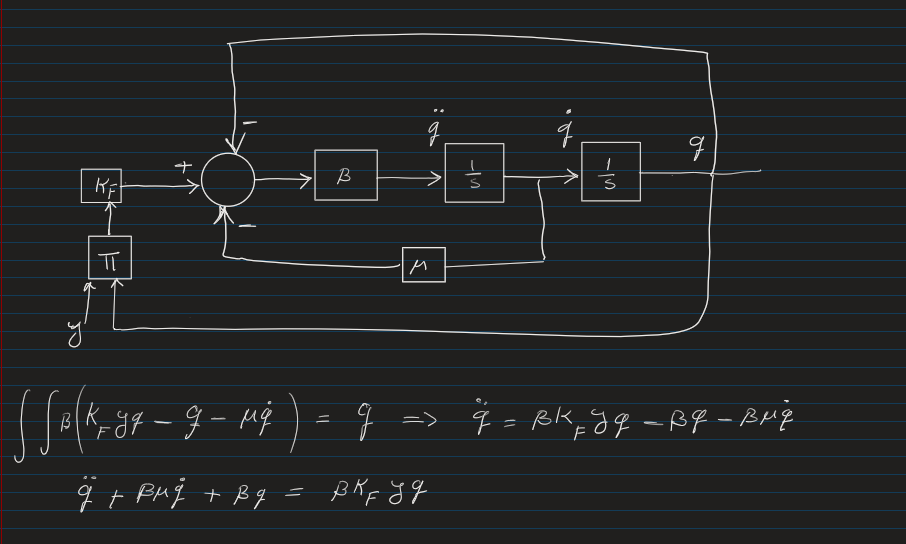

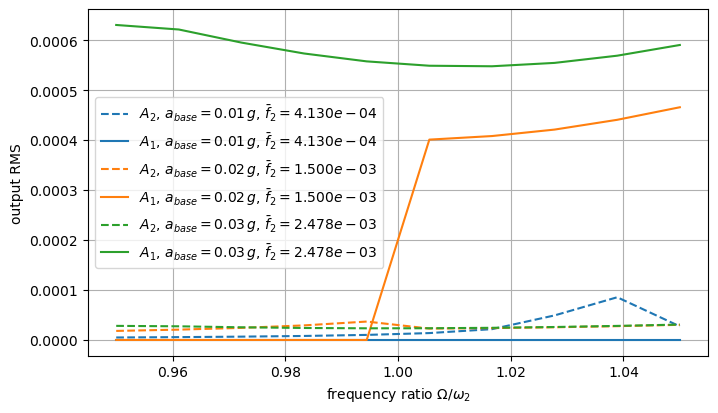

In [235]:
# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# extent = [f2_values[0], f2_values[-1], freq_ratio_values[0], freq_ratio_values[-1]]

# im0 = axs[0].imshow(A1, origin="lower", aspect="auto", extent=extent)
# axs[0].set_title(r"$A_1$ RMS (solve_ivp)")
# axs[0].set_xlabel(r"forcing amplitude $f_2$")
# axs[0].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im0, ax=axs[0], label="RMS")

# im1 = axs[1].imshow(A2, origin="lower", aspect="auto", extent=extent)
# axs[1].set_title(r"$A_2$ RMS (solve_ivp)")
# axs[1].set_xlabel(r"forcing amplitude $f_2$")
# axs[1].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im1, ax=axs[1], label="RMS")

# im2 = axs[2].imshow(RUNTIME, origin="lower", aspect="auto", extent=extent)
# axs[2].set_title("Runtime per case [s] (solve_ivp)")
# axs[2].set_xlabel(r"forcing amplitude $f_2$")
# axs[2].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im2, ax=axs[2], label="s")

# plt.show()
plt.rcdefaults()
pick_js = [0, len(a_base_values) // 2, len(a_base_values) - 1]
# pick_js = []
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    label_a2 = fr"$A_2$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    label_a1 = fr"$A_1$, $a_{{base}}={a_base_values_g[j]:.2f}\,g$, $\bar{{f}}_2={f2_bar_values[j]:.3e}$"
    l1, = plt.plot(freq_ratio_values, A2[:, j], "--",  label=label_a2)
    plt.plot(freq_ratio_values, A1[:, j], "-", color=l1.get_color(), label=label_a1)
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"output RMS")
# plt.title(r"$A_2$ frequency response slices (solve_ivp)")
plt.grid(True)
plt.legend()
plt.show()


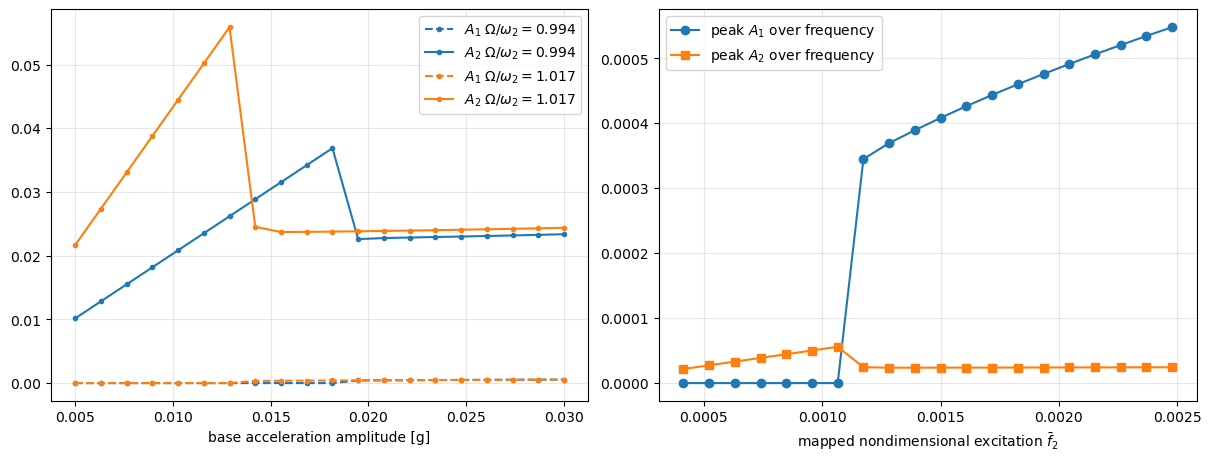

In [236]:

# ---- Amplitude vs excitation amplitude study ----
# 1) Fixed-frequency slices (near resonance).
target_ratios = [1.00, 1.02]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for idx in idxs:
    r = freq_ratio_values[idx]
    l1, = axs[0].plot(a_base_values_g, A1[idx, :], '.--', label=fr"$A_1 \; \Omega/\omega_2={r:.3f}$")
    axs[0].plot(a_base_values_g, A2[idx, :]*1000, '.-', color=l1.get_color(),label=fr"$A_2 \; \Omega/\omega_2={r:.3f}$")

axs[0].set_xlabel(r"base acceleration amplitude [g]")
axs[0].grid(True, alpha=0.3)
axs[0].legend()
idx = idxs[1]  # index for ratio closest to 1.00

axs[1].plot(f2_bar_values, A1[idx, :], "-o", label=r"peak $A_1$ over frequency")
axs[1].plot(f2_bar_values, A2[idx, :], "-s", label=r"peak $A_2$ over frequency")
axs[1].set_xlabel(r"mapped nondimensional excitation $\bar{f}_2$")
axs[1].grid(True, alpha=0.3)
axs[1].legend()



In [237]:
rom.sigma_r * 30e-3*9.8
w1
rom.omega[0]

np.float64(61.898675394244805)